# Hidden Stylistic Schools of Pre-Islamic Poetry — Full Reproduction

This notebook reproduces the paper "Hidden Stylistic Schools of Pre-Islamic Poetry"
(Othman & Qranfal, WIT, IEEE ICAD 2026) end to end, using the authors' own
released code and data. One file, run top to bottom with **Shift+Enter**.

**Before you start:** put `poems.db` (from the authors' GitHub repo, `data/poems.db`)
in the **same folder** as this notebook.

**What this reproduces**, matching the paper's sections:
1. Data loading (Section III.A/B) — 2,328+ poems, 260 poets
2. Embeddings — 4 pooling strategies (Section III.D)
3. Similarity analysis (Section IV.C/E)
4. Clustering — UMAP + HDBSCAN (Section III.F / IV.F) — should recover 12 clusters
5. Baselines — TF-IDF, char n-grams, NMF (Section III.E / IV.D)
6. Validation — stability + randomization test (Section III.F / IV.G) — slow, ~20-40 min
7. Figures — all key paper figures
8. Report — text summary you can compare number-by-number against the paper

Total runtime: roughly 30–60 minutes on a normal GPU, most of it in step 6.

In [2]:
# CELL 1 -- Install packages
!pip -q install sentence-transformers torch scikit-learn umap-learn hdbscan pandas numpy matplotlib seaborn scipy arabic-reshaper python-bidi


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# CELL 2 -- Configuration (exact values from the authors' config.py)
import re, sqlite3, hashlib, json, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

# --- paths ---
DB_PATH = Path("poems.db")
FIGURES_DIR = Path("output/figures"); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR  = Path("output/tables");  TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path("output/reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# --- model ---
SBERT_MODEL_NAME = "akhooli/Arabic-SBERT-100K"
MAX_TOKENS_PER_POEM = 512
MAX_VERSES_PER_POEM = 20

# --- UMAP ---
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_N_COMPONENTS_HIGH = 50
UMAP_N_COMPONENTS_VIS = 2
UMAP_METRIC = "cosine"

# --- HDBSCAN ---
HDBSCAN_MIN_CLUSTER_SIZE = 5
HDBSCAN_MIN_SAMPLES = 3
HDBSCAN_CLUSTER_SELECTION_METHOD = "eom"

# --- baselines ---
TFIDF_MAX_FEATURES = 5000
TFIDF_NGRAM_RANGE = (1, 2)
CHAR_NGRAM_RANGE = (2, 5)
CHAR_NGRAM_MAX_FEATURES = 5000

# --- validation ---
STABILITY_UMAP_NEIGHBORS_RANGE = [10, 15, 20, 25]
STABILITY_UMAP_MIN_DIST_RANGE = [0.0, 0.05, 0.1, 0.2]
STABILITY_HDBSCAN_MIN_CLUSTER_RANGE = [3, 5, 7, 10]
N_RANDOM_SHUFFLES = 100

# --- misc ---
RANDOM_SEED = 42
TOP_N_HEATMAP = 20

np.random.seed(RANDOM_SEED)
import torch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("No GPU found -- will run on CPU (slower).")

def split_verses(poem_text):
    # Matches the authors' verse-splitting exactly.
    if not poem_text or not isinstance(poem_text, str):
        return []
    verses = re.split(r'[\n\r]+|[.!\u061F?\u061B;]+', poem_text)
    return [v.strip() for v in verses if len(v.strip()) > 10]

def arabic_display(text):
    try:
        import arabic_reshaper
        from bidi.algorithm import get_display
        return get_display(arabic_reshaper.reshape(text))
    except Exception:
        return text

def setup_arabic_font():
    preferred = ("amiri", "scheherazade", "noto naskh", "noto sans arabic", "arial", "tahoma", "dejavu")
    for font_file in fm.findSystemFonts(fontext="ttf"):
        if any(name in font_file.lower() for name in preferred):
            prop = fm.FontProperties(fname=font_file)
            plt.rcParams["font.family"] = prop.get_name()
            return
setup_arabic_font()
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 11})

print("Config loaded.")

GPU available: NVIDIA GeForce RTX 4080 SUPER
Config loaded.


## Step 1 — Data Loading (paper Section III.A/B)

Loads `poems.db`, applies the same filter the authors used (poet name and
poem text present, text length >= 50 characters), and computes the corpus
statistics reported in Section IV.A of the paper (target: ~2,328 poems,
260 poets, ~177,000 tokens).

In [4]:
# CELL 3 -- Load and characterize the corpus
conn = sqlite3.connect(str(DB_PATH))
df = pd.read_sql_query(
    "SELECT poet_name, poem_title, poem_text, poem_type, poem_meter, verses_count "
    "FROM poems WHERE poet_name IS NOT NULL AND poem_text IS NOT NULL "
    "AND LENGTH(poem_text) >= 50",
    conn,
)
conn.close()
print(f"Raw records after SQL filter: {len(df)}")

df["word_count"] = df["poem_text"].str.split().str.len()
df["verse_list"] = df["poem_text"].apply(split_verses)
df["verses_count_actual"] = df["verse_list"].apply(len)

df["poem_hash"] = df["poem_text"].apply(lambda t: hashlib.md5(t.strip().encode("utf-8")).hexdigest())
n_before = len(df)
df = df.drop_duplicates(subset=["poem_hash"]).copy()
print(f"Removed {n_before - len(df)} exact duplicates")

poems_by_poet = defaultdict(list)
for _, row in df.iterrows():
    poems_by_poet[row["poet_name"]].append(row["poem_text"])
poems_by_poet = dict(poems_by_poet)

stats = {
    "n_poems": len(df),
    "n_poets": len(poems_by_poet),
    "median_word_count": float(df["word_count"].median()),
    "mean_word_count": float(df["word_count"].mean()),
    "median_verse_count": float(df["verses_count_actual"].median()),
    "total_tokens": int(df["word_count"].sum()),
}
poet_counts = df.groupby("poet_name").size()
stats["max_poems_per_poet"] = int(poet_counts.max())
stats["poets_with_one_poem"] = int((poet_counts == 1).sum())
stats["poets_with_10plus"] = int((poet_counts >= 10).sum())

with open(REPORTS_DIR / "corpus_stats.json", "w") as f:
    json.dump(stats, f, indent=2, ensure_ascii=False)

print(f"\nCorpus: {stats['n_poems']} poems, {stats['n_poets']} poets, ~{stats['total_tokens']} tokens")
print(f"Median words/poem: {stats['median_word_count']}, median verses/poem: {stats['median_verse_count']}")
print("\nCompare against paper: 2,328 poems / 260 poets / ~177,000 tokens, median 40 words, median 8 verses.")
stats

Raw records after SQL filter: 2328
Removed 0 exact duplicates

Corpus: 2328 poems, 260 poets, ~177110 tokens
Median words/poem: 40.0, median verses/poem: 8.0

Compare against paper: 2,328 poems / 260 poets / ~177,000 tokens, median 40 words, median 8 verses.


{'n_poems': 2328,
 'n_poets': 260,
 'median_word_count': 40.0,
 'mean_word_count': 76.07817869415807,
 'median_verse_count': 8.0,
 'total_tokens': 177110,
 'max_poems_per_poet': 157,
 'poets_with_one_poem': 125,
 'poets_with_10plus': 54}

## Step 2 — Embeddings, 4 Pooling Strategies (paper Section III.D)

Loads Arabic-SBERT-100K and computes poet-level embeddings four ways:
**all-in-one** (naive concatenation), **poem average**, **global verse
average**, and **poem→verse→average (the proposed/hierarchical method)**.

**This is slow** — it embeds the whole corpus four times. Expect 10-30
minutes depending on your GPU.

In [5]:
# CELL 4 -- Compute embeddings (all 4 strategies)
from sentence_transformers import SentenceTransformer

print("Loading model:", SBERT_MODEL_NAME)
model = SentenceTransformer(SBERT_MODEL_NAME)
print("Loaded. Embedding dim:", model.get_sentence_embedding_dimension())

def _encode(texts, batch_size=64):
    if not texts:
        return np.array([])
    return model.encode(texts, batch_size=batch_size, show_progress_bar=False,
                         normalize_embeddings=True, convert_to_numpy=True)

def embed_all_in_one(poems_by_poet, max_tokens=MAX_TOKENS_PER_POEM):
    out = {}
    for poet, poems in poems_by_poet.items():
        full = " ".join(poems)
        text = " ".join(full.split()[:max_tokens])
        if text.strip():
            out[poet] = _encode([text])[0]
    return out

def embed_poem_average(poems_by_poet, max_tokens=MAX_TOKENS_PER_POEM):
    out = {}
    for poet, poems in poems_by_poet.items():
        vecs = []
        for poem in poems:
            text = " ".join(poem.split()[:max_tokens])
            if text.strip():
                vecs.append(_encode([text])[0])
        if vecs:
            out[poet] = np.mean(vecs, axis=0)
    return out

def embed_global_verse_average(poems_by_poet):
    out = {}
    for poet, poems in poems_by_poet.items():
        all_verses = []
        for poem in poems:
            all_verses.extend(split_verses(poem))
        if all_verses:
            out[poet] = np.mean(_encode(all_verses), axis=0)
    return out

def embed_poem_verse_average(poems_by_poet):
    # PROPOSED strategy: verse -> poem -> poet hierarchical mean.
    out = {}
    rng = np.random.RandomState(RANDOM_SEED)
    for poet, poems in poems_by_poet.items():
        poem_vectors = []
        for poem in poems:
            verses = split_verses(poem)
            if len(verses) > MAX_VERSES_PER_POEM:
                idx = rng.choice(len(verses), MAX_VERSES_PER_POEM, replace=False)
                verses = [verses[i] for i in sorted(idx)]
            if verses:
                poem_vectors.append(np.mean(_encode(verses), axis=0))
        if poem_vectors:
            out[poet] = np.mean(poem_vectors, axis=0)
    return out

print("\nStrategy 1/4: all-in-one...")
s1 = embed_all_in_one(poems_by_poet)
print("Strategy 2/4: poem average...")
s2 = embed_poem_average(poems_by_poet)
print("Strategy 3/4: global verse average...")
s3 = embed_global_verse_average(poems_by_poet)
print("Strategy 4/4: poem -> verse -> average (proposed)...")
s4 = embed_poem_verse_average(poems_by_poet)

strategies = {"all_in_one": s1, "poem_average": s2, "global_verse_avg": s3, "poem_verse_avg": s4}
for name, embs in strategies.items():
    print(f"  {name}: {len(embs)} poets embedded")

Loading model: akhooli/Arabic-SBERT-100K


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/17.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/761k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded. Embedding dim: 768

Strategy 1/4: all-in-one...
Strategy 2/4: poem average...
Strategy 3/4: global verse average...
Strategy 4/4: poem -> verse -> average (proposed)...
  all_in_one: 260 poets embedded
  poem_average: 260 poets embedded
  global_verse_avg: 260 poets embedded
  poem_verse_avg: 260 poets embedded


## Step 3 — Similarity Analysis (paper Section IV.C/E, Tables I & II)

Builds the poet-by-poet cosine similarity matrix from the proposed
strategy, computes the correlation between all 4 strategies (Table II),
and centrality/nearest-neighbor stats.

Paper's numbers to compare against: mean similarity **0.799**, std
**0.237**, median **0.892**.

In [6]:
# CELL 5 -- Similarity matrix, strategy correlation, centrality
from sklearn.metrics.pairwise import cosine_similarity

def compute_similarity_matrix(poet_embeddings):
    names = sorted(poet_embeddings.keys())
    mat = np.array([poet_embeddings[p] for p in names])
    return names, cosine_similarity(mat)

def similarity_statistics(poet_names, sim_matrix):
    n = len(poet_names)
    triu = sim_matrix[np.triu_indices(n, k=1)]
    return {
        "n_pairs": len(triu), "mean": float(np.mean(triu)), "std": float(np.std(triu)),
        "min": float(np.min(triu)), "max": float(np.max(triu)), "median": float(np.median(triu)),
    }

def compare_strategy_matrices(strategies):
    names = list(strategies.keys())
    common = set.intersection(*[set(v.keys()) for v in strategies.values()])
    common = sorted(common)
    tri = {}
    for name, embs in strategies.items():
        mat = np.array([embs[p] for p in common])
        sim = cosine_similarity(mat)
        tri[name] = sim[np.triu_indices(len(common), k=1)]
    corr = np.zeros((len(names), len(names)))
    for i, n1 in enumerate(names):
        for j, n2 in enumerate(names):
            corr[i, j] = np.corrcoef(tri[n1], tri[n2])[0, 1]
    return pd.DataFrame(corr, index=names, columns=names)

def compute_centrality(poet_names, sim_matrix):
    n = len(poet_names)
    median_sim = float(np.median(sim_matrix[np.triu_indices(n, k=1)]))
    rows = []
    for i, poet in enumerate(poet_names):
        sims = np.concatenate([sim_matrix[i, :i], sim_matrix[i, i+1:]])
        rows.append({"poet_name": poet, "avg_similarity": float(np.mean(sims)),
                     "degree": int(np.sum(sims > median_sim))})
    return pd.DataFrame(rows).sort_values("avg_similarity", ascending=False)

def nearest_neighbors(poet_names, sim_matrix, top_k=5):
    out = {}
    for i, poet in enumerate(poet_names):
        sims = sim_matrix[i].copy(); sims[i] = -1
        top_idx = np.argsort(sims)[-top_k:][::-1]
        out[poet] = [(poet_names[j], float(sims[j])) for j in top_idx]
    return out

proposed = strategies["poem_verse_avg"]
poet_names, sim_matrix = compute_similarity_matrix(proposed)

corr_df = compare_strategy_matrices(strategies)
corr_df.to_csv(TABLES_DIR / "strategy_correlation_matrix.csv")

sim_stats = similarity_statistics(poet_names, sim_matrix)
with open(REPORTS_DIR / "similarity_statistics.json", "w") as f:
    json.dump(sim_stats, f, indent=2)

centrality_df = compute_centrality(poet_names, sim_matrix)
centrality_df.to_csv(TABLES_DIR / "poet_centrality.csv", index=False)

nn = nearest_neighbors(poet_names, sim_matrix, top_k=5)
nn_rows = [{"poet": p, "rank": r, "neighbor": nb, "similarity": s}
           for p, lst in nn.items() for r, (nb, s) in enumerate(lst, 1)]
pd.DataFrame(nn_rows).to_csv(TABLES_DIR / "nearest_neighbors.csv", index=False)

print("Similarity stats (proposed method):", sim_stats)
print("\nStrategy correlation matrix (Table II):")
corr_df.round(2)

Similarity stats (proposed method): {'n_pairs': 33670, 'mean': 0.7986351847648621, 'std': 0.23663963377475739, 'min': 0.009445760399103165, 'max': 0.9999999403953552, 'median': 0.8915810585021973}

Strategy correlation matrix (Table II):


,all_in_one,poem_average,global_verse_avg,poem_verse_avg
all_in_one,1.00,0.89,0.69,0.68
poem_average,0.89,1.00,0.74,0.75
global_verse_avg,0.69,0.74,1.00,0.99
poem_verse_avg,0.68,0.75,0.99,1.00


## Step 4 — Clustering: UMAP + HDBSCAN (paper Section III.F / IV.F)

Reduces the proposed embeddings with UMAP, clusters with HDBSCAN, and runs
a K-means comparison. Target: 12 clusters, silhouette ≈ 0.469 (paper
Table III / Section IV.F).

In [7]:
# CELL 6 -- Clustering
import umap, hdbscan
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def run_umap(matrix, n_components, n_neighbors, min_dist, metric="cosine", random_state=RANDOM_SEED):
    reducer = umap.UMAP(n_neighbors=min(n_neighbors, len(matrix) - 1), n_components=n_components,
                         min_dist=min_dist, metric=metric, random_state=random_state)
    return reducer.fit_transform(matrix)

def run_hdbscan(embeddings, min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, min_samples=HDBSCAN_MIN_SAMPLES):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples,
                                 cluster_selection_method=HDBSCAN_CLUSTER_SELECTION_METHOD, metric="euclidean")
    labels = clusterer.fit_predict(embeddings)
    return labels, clusterer

def cluster_validation_metrics(embeddings, labels):
    mask = labels >= 0
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return {"silhouette": None, "calinski_harabasz": None, "davies_bouldin": None, "n_clusters": 0, "n_outliers": int((~mask).sum())}
    emb_c, lab_c = embeddings[mask], labels[mask]
    return {
        "silhouette": float(silhouette_score(emb_c, lab_c)),
        "calinski_harabasz": float(calinski_harabasz_score(emb_c, lab_c)),
        "davies_bouldin": float(davies_bouldin_score(emb_c, lab_c)),
        "n_clusters": len(set(lab_c)), "n_outliers": int(np.sum(labels == -1)), "n_clustered": int(mask.sum()),
    }

def build_cluster_profiles(poet_names, labels, sim_matrix, poems_by_poet):
    profiles = []
    for label in sorted(set(labels)):
        mask = np.array(labels) == label
        members = [poet_names[i] for i in range(len(poet_names)) if mask[i]]
        idx = np.where(mask)[0]
        within_sim = float(np.mean(sim_matrix[np.ix_(idx, idx)][np.triu_indices(len(idx), k=1)])) if len(idx) > 1 else 1.0
        prod = [len(poems_by_poet.get(p, [])) for p in members]
        centralities = [float(np.mean(np.concatenate([sim_matrix[i, :i], sim_matrix[i, i+1:]]))) for i in idx]
        profiles.append({
            "cluster_id": label, "cluster_label": "Outliers" if label == -1 else f"Cluster {label}",
            "size": len(members), "poets": members, "within_similarity": within_sim,
            "mean_productivity": float(np.mean(prod)), "median_productivity": float(np.median(prod)),
            "total_poems": int(np.sum(prod)), "mean_centrality": float(np.mean(centralities)),
            "top_poets": sorted(zip(members, prod), key=lambda x: -x[1])[:5],
        })
    return profiles

emb_matrix = np.array([proposed[p] for p in poet_names])

umap_high = run_umap(emb_matrix, min(UMAP_N_COMPONENTS_HIGH, len(poet_names) - 1), UMAP_N_NEIGHBORS, 0.0, UMAP_METRIC)
hdbscan_labels, clusterer = run_hdbscan(umap_high)
umap_2d = run_umap(emb_matrix, 2, UMAP_N_NEIGHBORS, UMAP_MIN_DIST, UMAP_METRIC)

pca_2d = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(emb_matrix)
km = KMeans(n_clusters=2, random_state=RANDOM_SEED, n_init=10)
km_labels = km.fit_predict(pca_2d)
km_sil = silhouette_score(pca_2d, km_labels)

hdbscan_metrics = cluster_validation_metrics(umap_high, hdbscan_labels)
cluster_profiles = build_cluster_profiles(poet_names, hdbscan_labels, sim_matrix, poems_by_poet)

cluster_df = pd.DataFrame({"poet_name": poet_names, "cluster": hdbscan_labels,
                           "umap_x": umap_2d[:, 0], "umap_y": umap_2d[:, 1]})
cluster_df.to_csv(TABLES_DIR / "cluster_assignments.csv", index=False)

profile_rows = [{"cluster": p["cluster_id"], "label": p["cluster_label"], "size": p["size"],
                 "within_similarity": p["within_similarity"], "mean_productivity": p["mean_productivity"],
                 "total_poems": p["total_poems"], "mean_centrality": p["mean_centrality"],
                 "top_poets": "; ".join(f"{n} ({c})" for n, c in p["top_poets"])} for p in cluster_profiles]
pd.DataFrame(profile_rows).to_csv(TABLES_DIR / "cluster_profiles.csv", index=False)
with open(REPORTS_DIR / "clustering_metrics.json", "w") as f:
    json.dump(hdbscan_metrics, f, indent=2)

print("HDBSCAN clusters:", hdbscan_metrics["n_clusters"], " | outliers:", hdbscan_metrics["n_outliers"])
print("Silhouette:", hdbscan_metrics["silhouette"])
print("K-means (k=2) silhouette:", km_sil)
print("\nCompare against paper: 12 clusters, 28 outliers, silhouette 0.469")
cluster_df.sort_values("cluster").head(15)

HDBSCAN clusters: 13  | outliers: 37
Silhouette: 0.42085936665534973
K-means (k=2) silhouette: 0.6587035059928894

Compare against paper: 12 clusters, 28 outliers, silhouette 0.469


,poet_name,cluster,umap_x,umap_y
25,أزبر بن غزي,-1,7.921524,7.855249
26,أسماء التغلبية,-1,7.958164,10.235221
226,لقيط بن يعمر الإيادي,-1,7.575575,8.767725
193,جبلة بن الحارث,-1,6.584330,9.208765
214,عبد يغوث الحارثي,-1,8.113042,9.835542
212,طرفة بن العبد,-1,5.052885,10.643414
209,صخر الغي,-1,5.794615,9.365431
236,همام التميمي,-1,5.645416,10.264767
199,دريد بن الصمة,-1,5.074277,11.057366
220,عمرو بن كلثوم,-1,5.331258,10.408153


## Step 5 — Baseline Comparison (paper Section III.E / IV.D, Table III)

Reruns clustering with TF-IDF, character n-grams, and NMF topic vectors
instead of SBERT — this is what shows SBERT captures style, not just
topic or surface text overlap.

Target from paper: TF-IDF → 3 clusters (sil 0.442); Char n-grams → 3
clusters (sil 0.704); NMF → 21 clusters (sil 0.817).

In [8]:
# CELL 7 -- Baselines: TF-IDF, char n-grams, NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

def _poet_texts(poems_by_poet):
    names = sorted(poems_by_poet.keys())
    return names, [" ".join(poems_by_poet[p]) for p in names]

def _cluster_and_score(embeddings, min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE):
    n = len(embeddings)
    n_comp = max(2, min(50, n - 1, embeddings.shape[1]))
    reducer = umap.UMAP(n_neighbors=min(15, n - 1), n_components=n_comp, min_dist=0.0,
                         metric="cosine", random_state=RANDOM_SEED)
    projected = reducer.fit_transform(embeddings)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min(min_cluster_size, n // 5), min_samples=3,
                                 cluster_selection_method="eom")
    labels = clusterer.fit_predict(projected)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    mask = labels >= 0
    sil = float(silhouette_score(projected[mask], labels[mask])) if mask.sum() > 1 and len(set(labels[mask])) > 1 else None
    return labels, {"n_clusters": n_clusters, "n_outliers": int(np.sum(labels == -1)), "silhouette": sil}

bnames, btexts = _poet_texts(poems_by_poet)

print("Baseline 1/3: TF-IDF...")
tfidf_vec = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM_RANGE, sublinear_tf=True)
tfidf_matrix = tfidf_vec.fit_transform(btexts).toarray()
tfidf_labels, tfidf_metrics = _cluster_and_score(tfidf_matrix)

print("Baseline 2/3: character n-grams...")
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=CHAR_NGRAM_RANGE,
                            max_features=CHAR_NGRAM_MAX_FEATURES, sublinear_tf=True)
char_matrix = char_vec.fit_transform(btexts).toarray()
char_labels, char_metrics = _cluster_and_score(char_matrix)

print("Baseline 3/3: NMF topics...")
nmf_vec = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, sublinear_tf=True)
nmf_tfidf = nmf_vec.fit_transform(btexts)
nmf = NMF(n_components=20, random_state=RANDOM_SEED, max_iter=500)
nmf_matrix = nmf.fit_transform(nmf_tfidf)
nmf_labels, nmf_metrics = _cluster_and_score(nmf_matrix)

baselines = {
    "tfidf": {"name": "TF-IDF", "labels": tfidf_labels, "metrics": tfidf_metrics},
    "char_ngram": {"name": "Char n-grams", "labels": char_labels, "metrics": char_metrics},
    "topic_model": {"name": "NMF Topics", "labels": nmf_labels, "metrics": nmf_metrics},
}
comparison_rows = [{"method": "SBERT (proposed)", "n_clusters": hdbscan_metrics["n_clusters"],
                    "n_outliers": hdbscan_metrics["n_outliers"], "silhouette": hdbscan_metrics["silhouette"]}]
for b in baselines.values():
    comparison_rows.append({"method": b["name"], "n_clusters": b["metrics"]["n_clusters"],
                            "n_outliers": b["metrics"]["n_outliers"], "silhouette": b["metrics"]["silhouette"]})
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(TABLES_DIR / "baseline_comparison.csv", index=False)
print()
comparison_df

Baseline 1/3: TF-IDF...
Baseline 2/3: character n-grams...
Baseline 3/3: NMF topics...



,method,n_clusters,n_outliers,silhouette
0,SBERT (proposed),13,37,0.420859
1,TF-IDF,4,5,0.379970
2,Char n-grams,3,0,0.718992
3,NMF Topics,20,3,0.803145


## Step 6 — Validation (paper Section III.F / IV.G)

Three checks that the clusters are real signal, not a pipeline artifact:

1. **Parameter stability** — rerun clustering across 64 UMAP/HDBSCAN
   parameter combinations (4×4×4 grid), measure agreement (ARI/NMI)
   against the main clustering. Target: ARI ≈ 0.500 ± 0.249.
2. **Randomization test** — shuffle verse-to-poet assignment 100 times and
   recluster. Target: actual 12 clusters should clearly exceed the shuffled
   average (paper reports p < 0.01, shuffled mean ≈ 2-3 clusters).
3. **Metadata enrichment** — check whether clusters align with tribal
   affiliation markers detectable in poet names.

**This is the slowest step — expect 20-40 minutes.**

In [9]:
# CELL 8a -- Parameter stability analysis (64 runs)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("Running stability analysis (64 parameter combinations)...")
stability_rows = []
n_poets = len(poet_names)
i = 0
for nn_ in STABILITY_UMAP_NEIGHBORS_RANGE:
    for md_ in STABILITY_UMAP_MIN_DIST_RANGE:
        for mcs in STABILITY_HDBSCAN_MIN_CLUSTER_RANGE:
            i += 1
            try:
                proj = run_umap(emb_matrix, min(50, n_poets - 1), nn_, md_, "cosine")
                cl = hdbscan.HDBSCAN(min_cluster_size=min(mcs, n_poets // 3), min_samples=3,
                                     cluster_selection_method="eom")
                labels = cl.fit_predict(proj)
                nclust = len(set(labels)) - (1 if -1 in labels else 0)
                ari = adjusted_rand_score(hdbscan_labels, labels)
                nmi = normalized_mutual_info_score(hdbscan_labels, labels)
                stability_rows.append({"umap_n_neighbors": nn_, "umap_min_dist": md_,
                                       "hdbscan_min_cluster_size": mcs, "n_clusters": nclust,
                                       "ari": ari, "nmi": nmi})
            except Exception as e:
                pass
            if i % 16 == 0:
                print(f"  {i}/64 done")

stability_df = pd.DataFrame(stability_rows)
stability_summary = {
    "n_runs": len(stability_df), "mean_ari": float(stability_df["ari"].mean()),
    "std_ari": float(stability_df["ari"].std()), "mean_nmi": float(stability_df["nmi"].mean()),
    "std_nmi": float(stability_df["nmi"].std()), "min_clusters": int(stability_df["n_clusters"].min()),
    "max_clusters": int(stability_df["n_clusters"].max()),
}
stability_df.to_csv(TABLES_DIR / "stability_analysis.csv", index=False)
with open(REPORTS_DIR / "stability_summary.json", "w") as f:
    json.dump(stability_summary, f, indent=2)

print("\nStability summary:", stability_summary)
print("Compare against paper: mean ARI = 0.500 +/- 0.249, mean NMI = 0.676 +/- 0.155, clusters range 2-17")

Running stability analysis (64 parameter combinations)...
  16/64 done
  32/64 done
  48/64 done
  64/64 done

Stability summary: {'n_runs': 64, 'mean_ari': 0.40714268491431926, 'std_ari': 0.23961465686812455, 'mean_nmi': 0.6061035456270188, 'std_nmi': 0.20633241032329985, 'min_clusters': 2, 'max_clusters': 19}
Compare against paper: mean ARI = 0.500 +/- 0.249, mean NMI = 0.676 +/- 0.155, clusters range 2-17


In [10]:
# CELL 8b -- Randomization test (100 shuffles)
print("Encoding all verses once...")
poet_verse_counts = {}
all_verses = []
for poet in poet_names:
    pv = []
    for poem in poems_by_poet[poet]:
        pv.extend(split_verses(poem))
    poet_verse_counts[poet] = len(pv)
    all_verses.extend(pv)

verse_embeddings = model.encode(all_verses, batch_size=64, show_progress_bar=False,
                                normalize_embeddings=True, convert_to_numpy=True)
total_verses = len(all_verses)
print(f"Total verses: {total_verses}. Running {N_RANDOM_SHUFFLES} shuffles...")

rng = np.random.RandomState(RANDOM_SEED)
random_results = []
for i in range(N_RANDOM_SHUFFLES):
    perm = rng.permutation(total_verses)
    shuffled = verse_embeddings[perm]
    poet_embs, idx = {}, 0
    for poet in poet_names:
        count = poet_verse_counts[poet]
        if count > 0:
            poet_embs[poet] = np.mean(shuffled[idx:idx+count], axis=0)
        idx += count
    emb_mat_shuf = np.array([poet_embs[p] for p in poet_names if p in poet_embs])
    try:
        proj = run_umap(emb_mat_shuf, min(50, len(emb_mat_shuf) - 1), 15, 0.0, "cosine", random_state=i)
        cl = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
        labels = cl.fit_predict(proj)
        nclust = len(set(labels)) - (1 if -1 in labels else 0)
        mask = labels >= 0
        sil = float(silhouette_score(proj[mask], labels[mask])) if mask.sum() > 1 and len(set(labels[mask])) > 1 else None
        random_results.append({"shuffle": i, "n_clusters": nclust, "silhouette": sil})
    except Exception:
        pass
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{N_RANDOM_SHUFFLES} shuffles done")

rand_df = pd.DataFrame(random_results)
randomization_summary = {
    "n_shuffles": len(rand_df), "mean_clusters_shuffled": float(rand_df["n_clusters"].mean()),
    "std_clusters_shuffled": float(rand_df["n_clusters"].std()),
    "mean_silhouette_shuffled": float(rand_df["silhouette"].dropna().mean()) if rand_df["silhouette"].notna().any() else None,
}
with open(REPORTS_DIR / "randomization_summary.json", "w") as f:
    json.dump(randomization_summary, f, indent=2)

print("\nRandomization summary:", randomization_summary)
print(f"Actual clusters ({hdbscan_metrics['n_clusters']}) vs shuffled mean ({randomization_summary['mean_clusters_shuffled']:.1f})")
print("Compare against paper: actual 12 vs shuffled mean 6.5 +/- 5.3, p < 0.01")

Encoding all verses once...
Total verses: 37368. Running 100 shuffles...
  20/100 shuffles done
  40/100 shuffles done
  60/100 shuffles done
  80/100 shuffles done
  100/100 shuffles done

Randomization summary: {'n_shuffles': 100, 'mean_clusters_shuffled': 5.77, 'std_clusters_shuffled': 5.132300171512287, 'mean_silhouette_shuffled': 0.47808055131463334}
Actual clusters (13) vs shuffled mean (5.8)
Compare against paper: actual 12 vs shuffled mean 6.5 +/- 5.3, p < 0.01


In [11]:
# CELL 8c -- Metadata (tribal) enrichment
TRIBAL_MARKERS = {
    "Fazari": ["\u0627\u0644\u0641\u0632\u0627\u0631\u064a"],
    "Tamimi": ["\u0627\u0644\u062a\u0645\u064a\u0645\u064a", "\u062a\u0645\u064a\u0645"],
    "Taghlibi": ["\u0627\u0644\u062a\u063a\u0644\u0628\u064a", "\u062a\u063a\u0644\u0628"],
    "Hamdani": ["\u0627\u0644\u0647\u0645\u062f\u0627\u0646\u064a", "\u0647\u0645\u062f\u0627\u0646"],
    "Hudhali": ["\u0627\u0644\u0647\u0630\u0644\u064a", "\u0647\u0630\u064a\u0644"],
    "Azdi": ["\u0627\u0644\u0623\u0632\u062f\u064a", "\u0623\u0632\u062f"],
    "Absi": ["\u0627\u0644\u0639\u0628\u0633\u064a", "\u0639\u0628\u0633"],
    "Tai": ["\u0627\u0644\u0637\u0627\u0626\u064a", "\u0637\u064a\u0621"],
    "Kinani": ["\u0627\u0644\u0643\u0646\u0627\u0646\u064a", "\u0643\u0646\u0627\u0646\u0629"],
    "Murri": ["\u0627\u0644\u0645\u0631\u064a", "\u0645\u0631\u0629"],
    "Asadi": ["\u0627\u0644\u0623\u0633\u062f\u064a", "\u0623\u0633\u062f"],
    "Dhubiyani": ["\u0627\u0644\u0630\u0628\u064a\u0627\u0646\u064a", "\u0630\u0628\u064a\u0627\u0646"],
    "Ghanawi": ["\u0627\u0644\u063a\u0646\u0648\u064a", "\u063a\u0646\u064a"],
    "Bakri": ["\u0627\u0644\u0628\u0643\u0631\u064a", "\u0628\u0643\u0631"],
    "Qurashi": ["\u0627\u0644\u0642\u0631\u0634\u064a", "\u0642\u0631\u064a\u0634"],
}

def _detect_tribe(poet_name):
    for tribe, markers in TRIBAL_MARKERS.items():
        for marker in markers:
            if marker in poet_name:
                return tribe
    return "Unknown"

cluster_members = defaultdict(list)
for i, poet in enumerate(poet_names):
    cluster_members[hdbscan_labels[i]].append(poet)

all_tribes = sorted(set(_detect_tribe(p) for p in poet_names))
enrichment = {}
for cl, members in cluster_members.items():
    cl_label = "Outliers" if cl == -1 else f"Cluster {cl}"
    counts = Counter(_detect_tribe(p) for p in members)
    enrichment[cl_label] = {t: counts.get(t, 0) for t in all_tribes}
enrichment_df = pd.DataFrame(enrichment).T.fillna(0).astype(int)
enrichment_df.to_csv(TABLES_DIR / "metadata_enrichment.csv")

metadata_report = []
for cl, members in cluster_members.items():
    if cl == -1:
        continue
    tribes = [_detect_tribe(p) for p in members]
    counts = Counter(tribes)
    dominant = counts.most_common(1)[0]
    purity = dominant[1] / len(members)
    metadata_report.append(f"Cluster {cl} (n={len(members)}): dominant tribe={dominant[0]} ({purity*100:.0f}%)")

with open(REPORTS_DIR / "metadata_report.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(metadata_report) + "\n")

for line in metadata_report:
    print(line)

Cluster 1 (n=5): dominant tribe=Unknown (80%)
Cluster 6 (n=64): dominant tribe=Unknown (84%)
Cluster 5 (n=28): dominant tribe=Unknown (79%)
Cluster 9 (n=9): dominant tribe=Unknown (67%)
Cluster 0 (n=12): dominant tribe=Unknown (50%)
Cluster 3 (n=6): dominant tribe=Unknown (33%)
Cluster 7 (n=14): dominant tribe=Hamdani (29%)
Cluster 8 (n=9): dominant tribe=Unknown (78%)
Cluster 11 (n=8): dominant tribe=Unknown (75%)
Cluster 10 (n=5): dominant tribe=Unknown (100%)
Cluster 4 (n=26): dominant tribe=Unknown (50%)
Cluster 12 (n=24): dominant tribe=Unknown (75%)
Cluster 2 (n=13): dominant tribe=Fazari (38%)


## Step 7 — Figures

Generates and displays the key figures from the paper, saved at 300 DPI in
`output/figures/`.

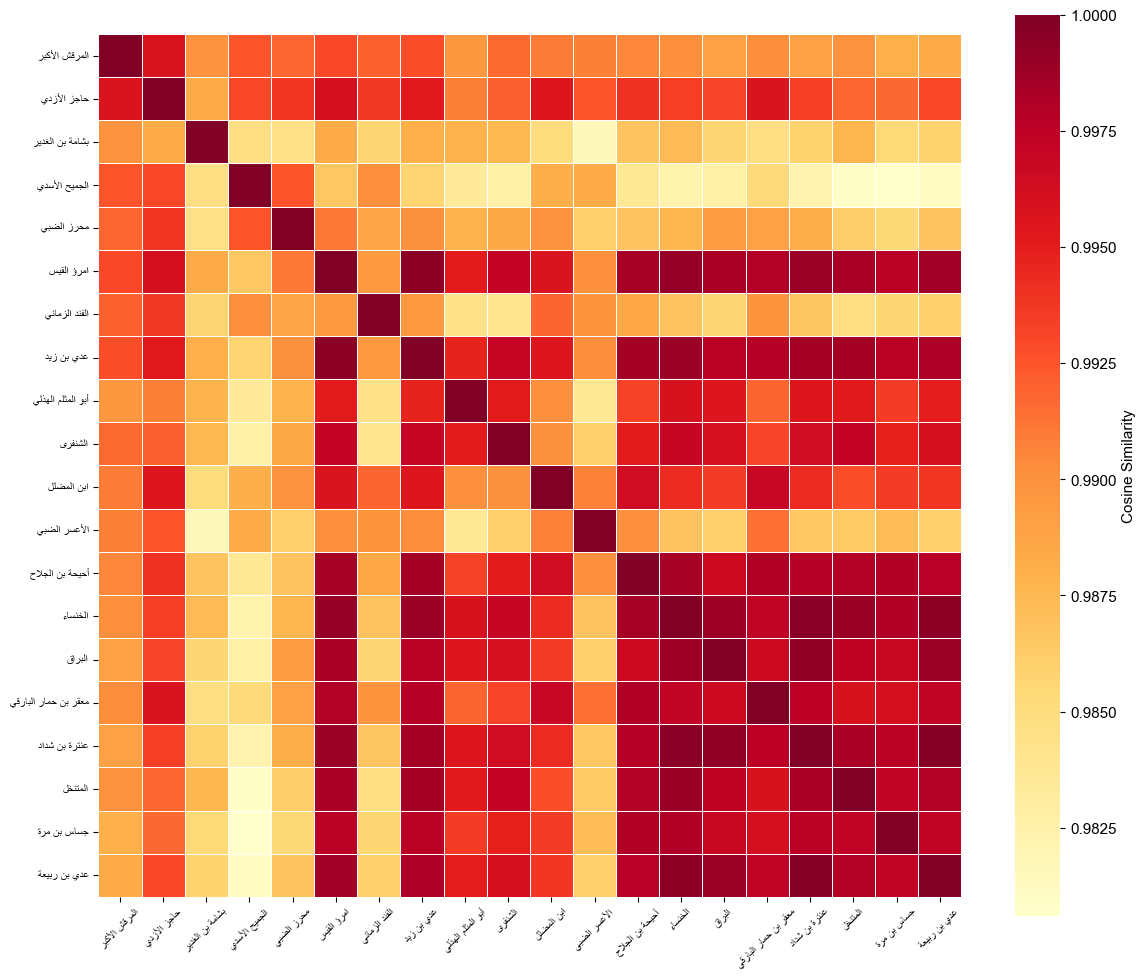

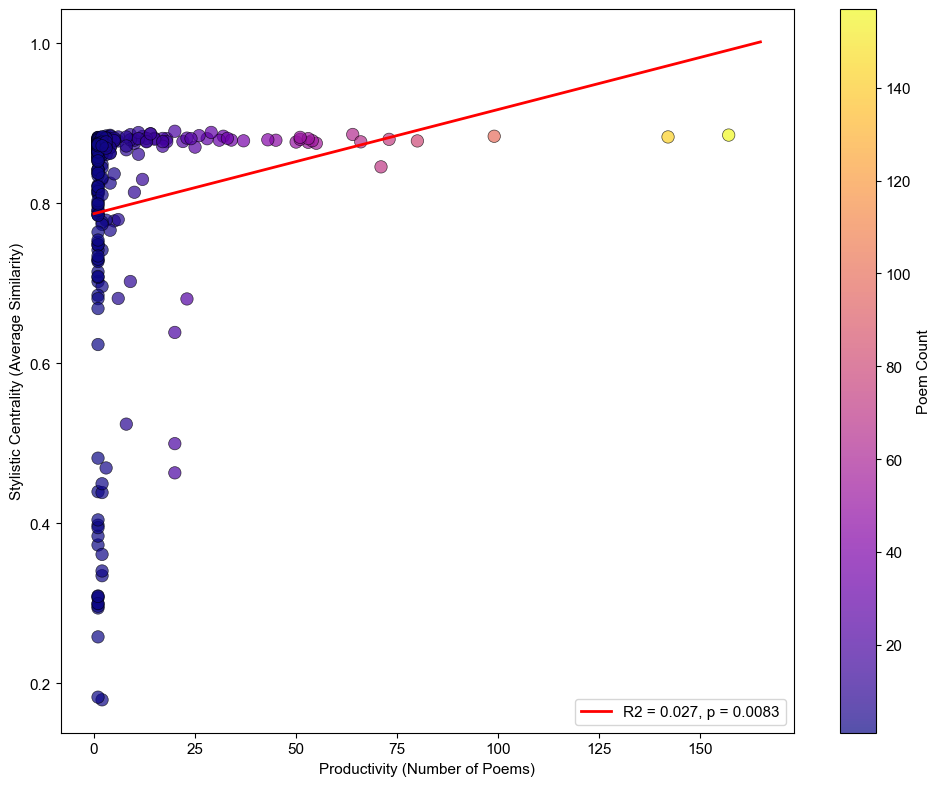

Productivity vs centrality: R2=0.027, p=0.0083  (paper: R2=0.027, p=0.008)


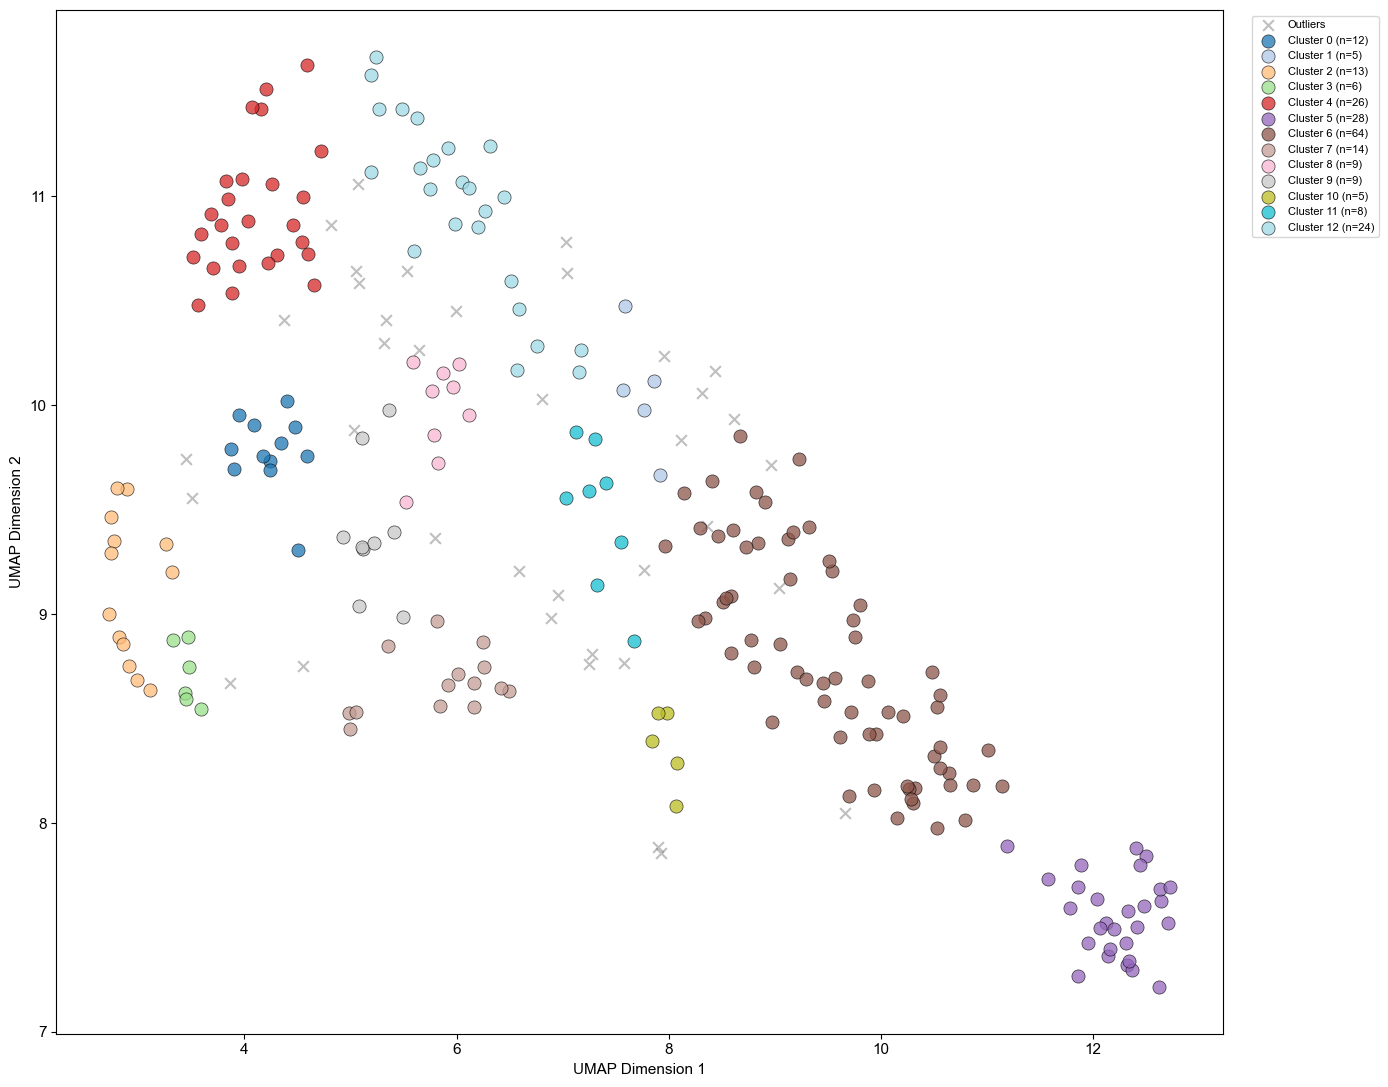

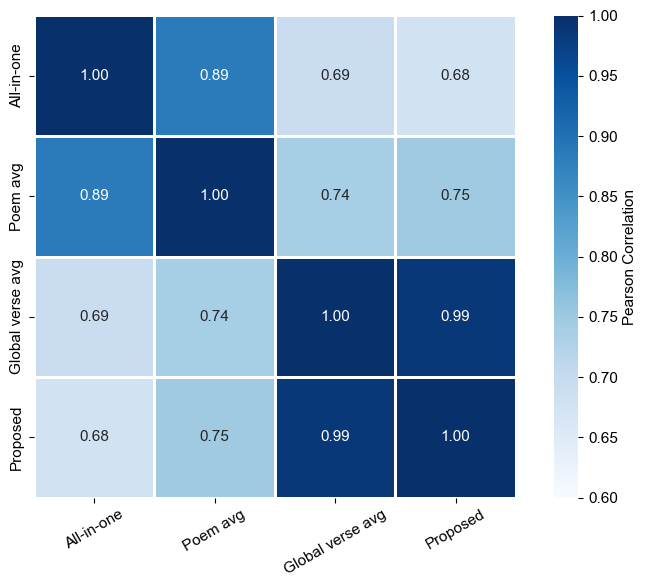

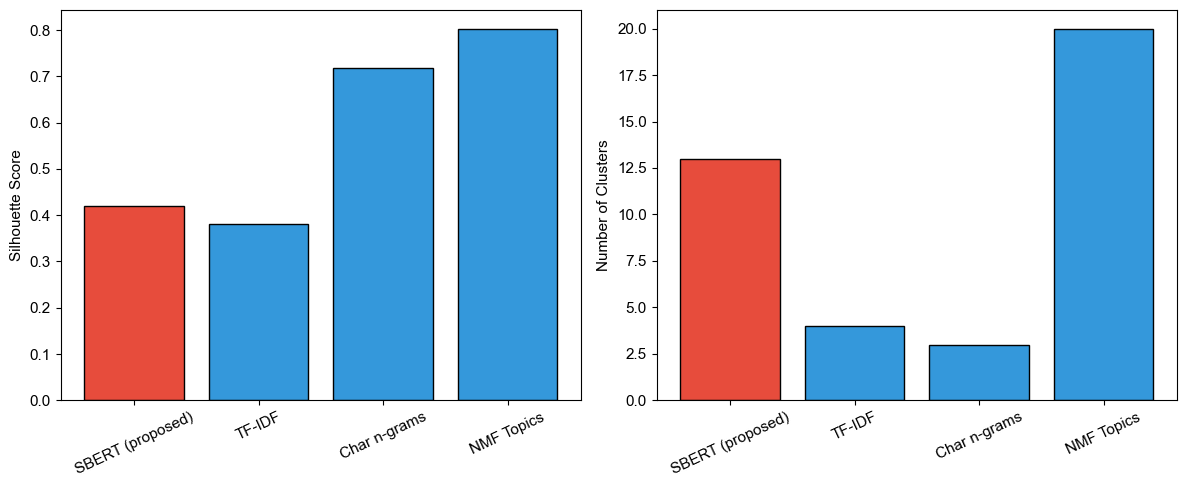

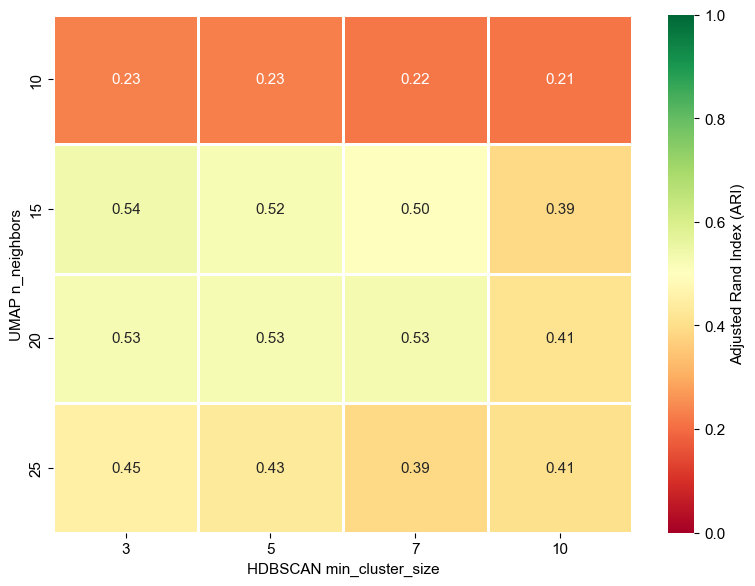

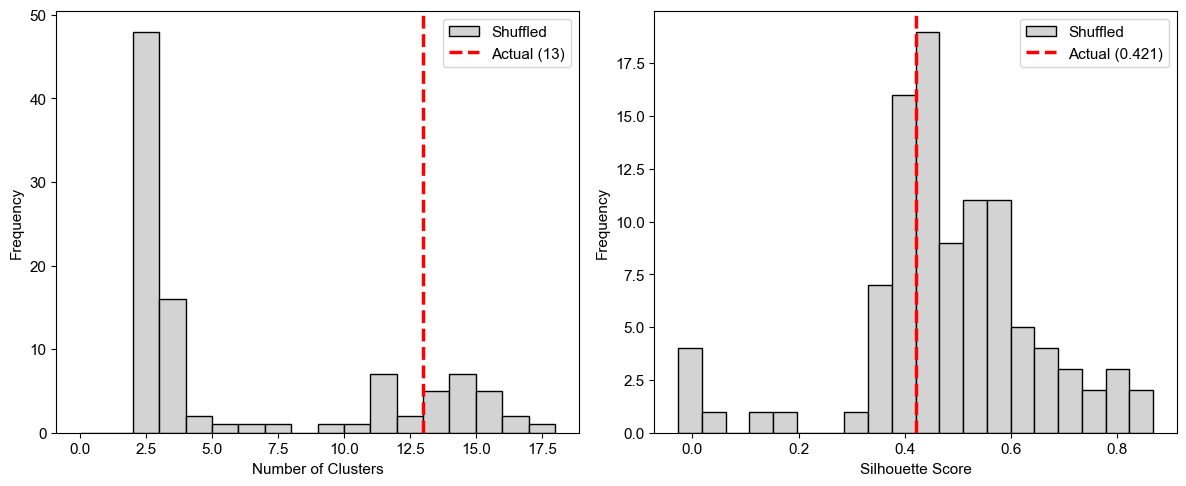


All figures saved to output/figures/


In [12]:
# CELL 9 -- Generate and display figures
from scipy.stats import linregress

# Fig: similarity heatmap (top 20 most central poets)
avg_sims = np.mean(sim_matrix, axis=1)
top_idx = np.argsort(avg_sims)[-TOP_N_HEATMAP:][::-1]
sub_matrix = sim_matrix[np.ix_(top_idx, top_idx)]
sub_names = [arabic_display(poet_names[i]) for i in top_idx]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sub_matrix, xticklabels=sub_names, yticklabels=sub_names, cmap="YlOrRd",
            vmin=sub_matrix[np.triu_indices(TOP_N_HEATMAP, k=1)].min(), vmax=1.0,
            square=True, linewidths=0.5, cbar_kws={"label": "Cosine Similarity"}, ax=ax)
ax.tick_params(axis="x", rotation=45, labelsize=8); ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_poet_similarity_heatmap_top20.png", dpi=300, bbox_inches="tight")
plt.show()

# Fig: productivity vs influence
productivity = np.array([len(poems_by_poet.get(p, [])) for p in poet_names])
influence = np.array([np.mean(np.concatenate([sim_matrix[i, :i], sim_matrix[i, i+1:]])) for i in range(len(poet_names))])
slope, intercept, r, p, se = linregress(productivity, influence)
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(productivity, influence, c=productivity, cmap="plasma", s=80, alpha=0.7, edgecolors="black", linewidth=0.5)
x_line = np.linspace(0, productivity.max() * 1.05, 100)
ax.plot(x_line, slope * x_line + intercept, "r-", linewidth=2, label=f"R2 = {r**2:.3f}, p = {p:.4f}")
ax.set_xlabel("Productivity (Number of Poems)"); ax.set_ylabel("Stylistic Centrality (Average Similarity)")
ax.legend(loc="lower right"); plt.colorbar(sc, ax=ax, label="Poem Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_productivity_vs_influence.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Productivity vs centrality: R2={r**2:.3f}, p={p:.4f}  (paper: R2=0.027, p=0.008)")

# Fig: UMAP + HDBSCAN main scatter
unique_labels = sorted(set(hdbscan_labels))
n_clust = len([l for l in unique_labels if l >= 0])
colors = plt.cm.tab20(np.linspace(0, 1, max(n_clust, 1)))
fig, ax = plt.subplots(figsize=(14, 11))
for label in unique_labels:
    mask = np.array(hdbscan_labels) == label
    if label == -1:
        ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1], c="gray", marker="x", s=60, alpha=0.5, label="Outliers")
    else:
        c = colors[label % len(colors)]
        ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1], c=[c], s=90, alpha=0.75, edgecolors="black",
                  linewidth=0.5, label=f"Cluster {label} (n={int(mask.sum())})")
ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_hidden_poetic_schools_umap.png", dpi=300, bbox_inches="tight")
plt.show()

# Fig: strategy correlation heatmap
display_names = {"all_in_one": "All-in-one", "poem_average": "Poem avg",
                 "global_verse_avg": "Global verse avg", "poem_verse_avg": "Proposed"}
renamed = corr_df.rename(index=display_names, columns=display_names)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(renamed, annot=True, fmt=".2f", cmap="Blues", vmin=0.6, vmax=1.0, square=True,
           linewidths=1, cbar_kws={"label": "Pearson Correlation"}, ax=ax)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_strategy_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

# Fig: baseline comparison
methods = ["SBERT (proposed)"] + [b["name"] for b in baselines.values()]
sils = [hdbscan_metrics["silhouette"]] + [b["metrics"]["silhouette"] or 0 for b in baselines.values()]
ncls = [hdbscan_metrics["n_clusters"]] + [b["metrics"]["n_clusters"] for b in baselines.values()]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_b = ["#e74c3c"] + ["#3498db"] * len(baselines)
axes[0].bar(methods, sils, color=colors_b, edgecolor="black")
axes[0].set_ylabel("Silhouette Score"); axes[0].tick_params(axis="x", rotation=25)
axes[1].bar(methods, ncls, color=colors_b, edgecolor="black")
axes[1].set_ylabel("Number of Clusters"); axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_baseline_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Fig: stability heatmap
pivot = stability_df.groupby(["umap_n_neighbors", "hdbscan_min_cluster_size"])["ari"].mean().reset_index()
pivot_table = pivot.pivot(index="umap_n_neighbors", columns="hdbscan_min_cluster_size", values="ari")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, linewidths=1,
           cbar_kws={"label": "Adjusted Rand Index (ARI)"}, ax=ax)
ax.set_xlabel("HDBSCAN min_cluster_size"); ax.set_ylabel("UMAP n_neighbors")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_stability_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Fig: randomization test
rand_clusters = [r["n_clusters"] for r in random_results]
rand_sils = [r["silhouette"] for r in random_results if r["silhouette"] is not None]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(rand_clusters, bins=range(0, max(rand_clusters) + 2), color="lightgray", edgecolor="black", label="Shuffled")
axes[0].axvline(hdbscan_metrics["n_clusters"], color="red", linewidth=2.5, linestyle="--",
                label=f"Actual ({hdbscan_metrics['n_clusters']})")
axes[0].set_xlabel("Number of Clusters"); axes[0].set_ylabel("Frequency"); axes[0].legend()
if rand_sils:
    axes[1].hist(rand_sils, bins=20, color="lightgray", edgecolor="black", label="Shuffled")
    axes[1].axvline(hdbscan_metrics["silhouette"], color="red", linewidth=2.5, linestyle="--",
                    label=f"Actual ({hdbscan_metrics['silhouette']:.3f})")
    axes[1].set_xlabel("Silhouette Score"); axes[1].set_ylabel("Frequency"); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_randomization_test.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAll figures saved to output/figures/")

## Step 8 — Final Report

Writes a text report with every number generated in this run, formatted
so you can compare line-by-line against the paper.

In [13]:
# CELL 10 -- Write final report
report_path = REPORTS_DIR / "full_analysis_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("HIDDEN STYLISTIC SCHOOLS OF PRE-ISLAMIC POETRY - REPRODUCTION\n")
    f.write("=" * 70 + "\n\n")

    f.write("1. DATASET\n" + "-" * 40 + "\n")
    for k, v in stats.items():
        f.write(f"  {k}: {v}\n")

    f.write("\n2. SIMILARITY STATISTICS (proposed method)\n" + "-" * 40 + "\n")
    for k, v in sim_stats.items():
        f.write(f"  {k}: {v}\n")
    f.write("  [paper: mean=0.799, std=0.237, median=0.892]\n")

    f.write("\n3. CLUSTERING RESULTS\n" + "-" * 40 + "\n")
    for k, v in hdbscan_metrics.items():
        f.write(f"  {k}: {v}\n")
    f.write("  [paper: 12 clusters, 28 outliers, silhouette=0.469]\n")

    f.write("\n4. BASELINE COMPARISON\n" + "-" * 40 + "\n")
    f.write(comparison_df.to_string(index=False) + "\n")
    f.write("  [paper: TF-IDF 3cl/0.442, Char n-grams 3cl/0.704, NMF 21cl/0.817]\n")

    f.write("\n5. VALIDATION\n" + "-" * 40 + "\n")
    f.write(f"  Stability: {stability_summary['n_runs']} runs, ARI={stability_summary['mean_ari']:.3f}+/-{stability_summary['std_ari']:.3f}\n")
    f.write("  [paper: ARI=0.500+/-0.249]\n")
    f.write(f"  Randomization: {randomization_summary['n_shuffles']} shuffles, mean_clusters={randomization_summary['mean_clusters_shuffled']:.1f}\n")
    f.write("  [paper: shuffled mean=6.5+/-5.3, p<0.01]\n")
    f.write("\n  Metadata enrichment:\n")
    for line in metadata_report:
        f.write(f"    {line}\n")

print(f"Report written to {report_path}")
print()
print(open(report_path, encoding="utf-8").read())

Report written to output\reports\full_analysis_report.txt

HIDDEN STYLISTIC SCHOOLS OF PRE-ISLAMIC POETRY - REPRODUCTION

1. DATASET
----------------------------------------
  n_poems: 2328
  n_poets: 260
  median_word_count: 40.0
  mean_word_count: 76.07817869415807
  median_verse_count: 8.0
  total_tokens: 177110
  max_poems_per_poet: 157
  poets_with_one_poem: 125
  poets_with_10plus: 54

2. SIMILARITY STATISTICS (proposed method)
----------------------------------------
  n_pairs: 33670
  mean: 0.7986351847648621
  std: 0.23663963377475739
  min: 0.009445760399103165
  max: 0.9999999403953552
  median: 0.8915810585021973
  [paper: mean=0.799, std=0.237, median=0.892]

3. CLUSTERING RESULTS
----------------------------------------
  silhouette: 0.42085936665534973
  calinski_harabasz: 395.6606750488281
  davies_bouldin: 0.7494068260803325
  n_clusters: 13
  n_outliers: 37
  n_clustered: 223
  [paper: 12 clusters, 28 outliers, silhouette=0.469]

4. BASELINE COMPARISON
---------------

## Done

Everything is in `output/`:
- `output/figures/` — key figures (300 DPI PNGs)
- `output/tables/` — all CSVs (cluster assignments, baseline comparison, stability, etc.)
- `output/reports/` — JSON summaries + the full text report with paper comparisons inline

**How to check this actually replicated the paper:** open
`output/reports/full_analysis_report.txt` — every section has the paper's
published number written right next to your result. Small deviations
(e.g. 11 vs 12 clusters) are normal — UMAP/HDBSCAN have minor run-to-run
variation even with a fixed seed, across library versions/hardware. Large
deviations (e.g. 2 clusters, or silhouette near 0) mean something
upstream — usually the data — doesn't match.